In [1]:
%load_ext autoreload
%autoreload 2
%load_ext rpy2.ipython

In [4]:
import ibis
import pandas as pd

import src
from src.load import DataLoader

ibis.options.interactive = True
r_colormap = src.r_colormap_name
r_out = str(src.OUT)
pd.options.display.float_format = "{:.1f}".format

In [4]:
%%R -i r_colormap -i r_out

suppressMessages(library(tidyverse))
library(ggplot2)
library(ggeffects)
library(here)
library(ggpubr)

options(scipen = 999)

cmap <- setNames(r_colormap$color, r_colormap$channel)

here() starts at /Users/lukas/git/ytpop
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/nix/store/8dk64qa8p4m00rnldm9vs0qy0zng8b84-apple-sdk-11.3/Library’ contains no packages


# Load Data

In [5]:
dl = DataLoader()

videos = dl.channels().join(dl.videos(filtered=True), "channel_id").to_pandas()

sentences = dl.sentences(filtered=True).join(dl.popbert(filtered=False), "sentence_id").to_pandas()

sents = sentences.groupby("video_id", observed=True).agg(
    n_sents=("video_id", "size"),
    n_elite=("elite", "sum"),
    n_pplcentr=("pplcentr", "sum"),
    avg_elite=("elite", "mean"),
    avg_pplcentr=("pplcentr", "mean"),
)

# Dataset Summary Table

In [6]:
channel_overview = (
    videos.loc[videos.video_was_live == False]
    .merge(sents, on="video_id", how="left")
    .groupby("channel", observed=True)
    .agg(
        chFollowers=("channel_follower_count", "first"),
        nShortVideos=("video_is_short", lambda x: (x == 1).sum()),
        nLongVideos=("video_is_short", lambda x: (x == 0).sum()),
        nTotalVideos=("video_was_live", lambda x: (x == 0).sum()),
        nLikesNA=("video_likes", lambda x: x.isna().sum()),
        meanViews=("video_views", "mean"),
        medianViews=("video_views", "median"),
        meanLikes=("video_likes", "mean"),
        medianLikes=("video_likes", "median"),
        meanVideoLen=("video_duration", "mean"),
        nSentences=("n_sents", "sum"),
        first_video=("video_datetime_upload", "min"),
        latest_video=("video_datetime_upload", "max"),
    )
)

In [7]:
inlines = src.OUT / "manuscript/inlines"
inlines.mkdir(exist_ok=True)

In [8]:
# number of broken transcripts

broken_transcripts = dl.broken_transcripts(filtered=True).to_pandas()
n_broken = len(broken_transcripts)

n_broken = f"{n_broken:,.0f}"
p = inlines / "n_broken.txt"
p.unlink(missing_ok=True)
p.write_text(n_broken)
print(f"faulty transcripts: {n_broken}")

faulty transcripts: 142


In [9]:
# sum of durations

sum_of_seconds = videos.video_duration.sum()
hour_duration = f"{round(sum_of_seconds / 60 / 60, 1):,.1f}"
p = inlines / "sum_duration.txt"
p.unlink(missing_ok=True)
p.write_text(hour_duration)
print(f"Total sum of video durations: {hour_duration} hours")

Total sum of video durations: 2,339.7 hours


In [10]:
# number of videos

count_videos = len(videos)
count_videos = f"{count_videos:,.0f}"
p = inlines / "n_videos.txt"
p.unlink(missing_ok=True)
p.write_text(count_videos)
print(f"Total number of valid videos: {count_videos}")

Total number of valid videos: 19,347


In [11]:
# number of sentencs

count_sents = len(sentences)
count_sents = f"{count_sents:,.0f}"
p = inlines / "n_sents.txt"
p.unlink(missing_ok=True)
p.write_text(count_sents)
print(f"Total number of valid sentences: {count_sents}")

Total number of valid sentences: 1,282,738


In [12]:
summary_table = channel_overview.drop(["first_video", "latest_video"], axis=1)

summary_table

,chFollowers,nShortVideos,nLongVideos,nTotalVideos,nLikesNA,meanViews,medianViews,meanLikes,medianLikes,meanVideoLen,nSentences
channel,,,,,,,,,,,
AfD BT,539000,665,5562,6227,0,54654.2,16714.0,4443.8,2062.0,411.4,378326
AfD DE,340000,654,1245,1899,110,56958.2,20265.0,4493.6,2610.0,541.3,173464
CDU/CSU BT,8050,461,675,1136,1030,3536.8,273.5,137.2,25.5,512.5,81172
CDU/CSU DE,30800,680,391,1071,5,22598.4,1299.0,172.0,29.0,513.0,88183
FDP BT,24500,298,346,644,1,24525.5,1695.0,291.9,60.0,379.7,39222
FDP DE,29600,433,325,758,757,24372.7,1243.5,104.0,104.0,527.3,57468
Greens BT,3000,140,93,233,0,4642.5,1003.0,57.6,17.0,333.3,11572
Greens DE,36500,237,433,670,7,16554.6,1423.5,209.5,35.0,588.9,55776
Left BT new,3280,182,157,339,0,1297.0,246.0,74.3,14.0,203.1,11986


In [13]:
path = src.OUT / "tables/videos_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "chFollowers",
        "nShortVideos",
        "nLongVideos",
        "nTotalVideos",
        "meanVideoLen",
        "nSentences",
    ]
].to_csv(path)

In [14]:
path = src.OUT / "tables/channel_descriptives.csv"
path.unlink(missing_ok=True)
summary_table[["meanViews", "medianViews", "meanLikes", "medianLikes"]].to_csv(path)

# View Count Violin Plot

In [15]:
df = videos.merge(sents, on="video_id")

In addition: Warning messages:
1: Removed 2000 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
2: Removed 2000 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
3: Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes. 


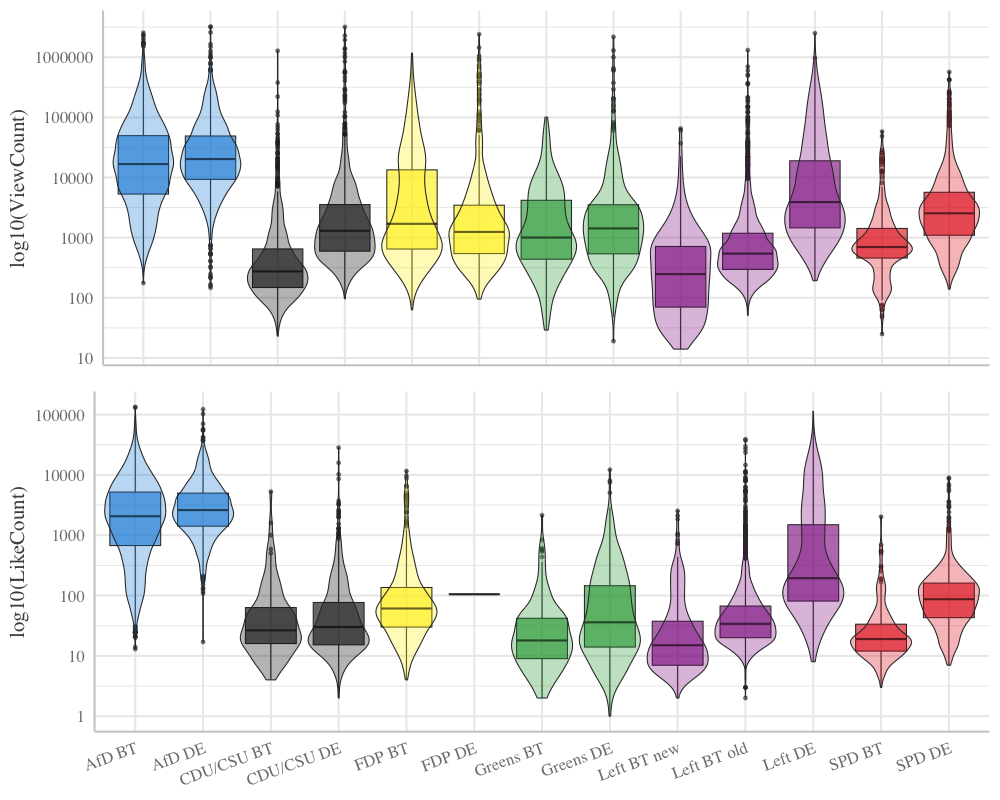

In [26]:
%%R -i df -w 1000 -h 800

df_plot <- df %>%
   mutate(
      likes = video_likes + 1,
      views = video_views + 1,
)

view_plot = ggplot(df_plot, aes(x=channel, y=views, fill=channel)) +
   geom_boxplot(alpha=0.6) +
   geom_violin(alpha=0.3, trim=T, scale="width") +
   scale_y_continuous(trans=scales::log10_trans(), breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 21
   ) +
   theme(
      # axis.text.x=element_text(angle=20, hjust=1),
      axis.text.x=element_blank(),
      axis.ticks.x=element_blank(),
      axis.title.x=element_blank(),
      legend.position = "none"
   ) +
   # xlab("Party") +
   ylab("log10(ViewCount)")

like_plot = ggplot(df_plot, aes(x=channel, y=likes, fill=channel)) +
   geom_boxplot(alpha=0.6) +
   geom_violin(alpha=0.3, trim=T, scale="width") +
   scale_y_continuous(trans=scales::log10_trans(), breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 21
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none",
      axis.title.x=element_blank()
   ) +
   ylab("log10(LikeCount)")


out <- ggarrange(view_plot, like_plot, ncol=1, heights=c(1,1.1))

p <- here(r_out, "/figures/view_count.svg")
if (file.exists(p)) file.remove(p)
ggsave(p, width=12.4, height=12.4)
out

# Populism Amount Plot

In [ ]:
%%R -i df -w 1000 -h 800

df_plot <- df %>%
   mutate(
      elite = (n_elite / n_sents * 100) + 1,
      pplcentr = (n_pplcentr / n_sents * 100) + 1,
)

elite_plot = ggplot(df_plot, aes(x=channel, y=elite, fill=channel)) +
   geom_boxplot(alpha=0.6, outliers=F, coef=0.5) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 22
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   ylab("% Anti-Elitism")

pplcentr_plot = ggplot(df_plot, aes(x=channel, y=pplcentr, fill=channel)) +
   geom_boxplot(alpha=0.6, outliers=F, coef=0.5) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 22
   ) +
   theme(
      axis.text.x=element_text(angle=20, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   ylab("% People-Centrism")


ggarrange(elite_plot, pplcentr_plot, ncol=2)

p <- here(r_out, "/figures/populism_per_party.svg")
if (file.exists(p)) file.remove(p)
ggsave(p, width=12.4, height=9.0)